In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering import AgglomerativeClustering
from sklearn.metrics import silhouette_score


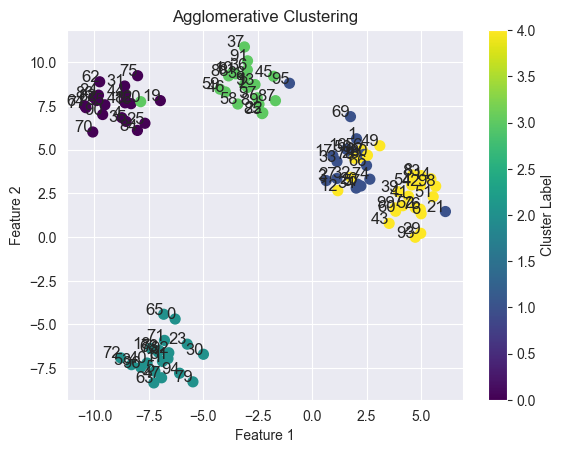

In [13]:
X, y = make_blobs(n_samples=100, centers=5, cluster_std=1,random_state=42)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=5, n_clusters=5,linkage="ward")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [14]:
model.compute_wcss()

np.float64(287.6679725295237)

## Plots for Silhouette Scores for different values of  $\tau$
an average silhouette width of over 0.7 is considered to be "strong", a value over 0.5 "reasonable" and over 0.25 "weak"

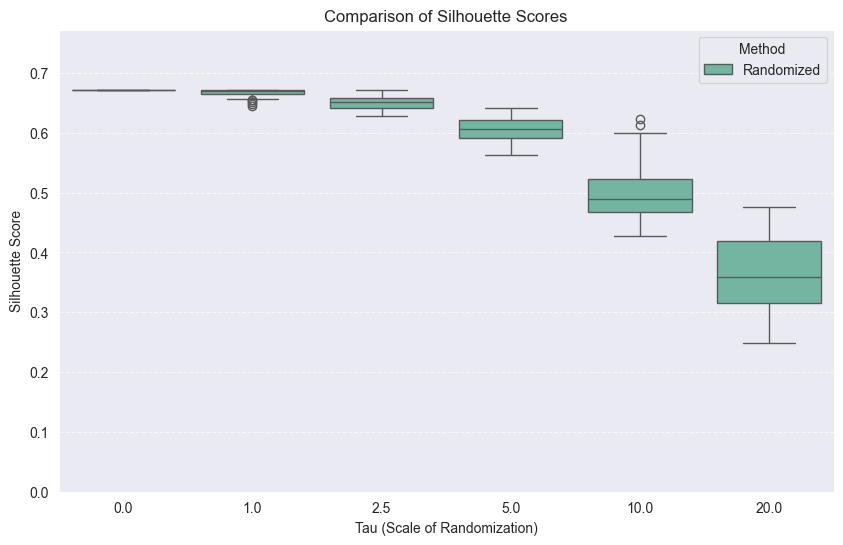

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define a range of tau values
n = 200
tau_values = [0,1,2.5,5,10,20]
n_runs = 50
n_clusters = 5  
# Data collection
results = []

for tau in tau_values:
    for _ in range(n_runs):
        X, y = make_blobs(n_samples=n, centers=5, cluster_std=1,random_state=42)
        # Randomized hierarchical clustering
        randomized_clustering = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
        randomized_clustering.fit()
        randomized_score = randomized_clustering.compute_silhouette_score()
        results.append({'Tau': tau, 'Method': 'Randomized', 'Silhouette Score': randomized_score})

# Convert results to a DataFrame
df = pd.DataFrame(results)

# Create side-by-side boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tau', y='Silhouette Score', hue='Method', palette='Set2')
plt.title('Comparison of Silhouette Scores')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('Silhouette Score')
plt.legend(title='Method')
y_max = df['Silhouette Score'].max() 
plt.ylim(0, y_max + 0.1) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Plot of within-cluster sum of square
$$
WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2
$$

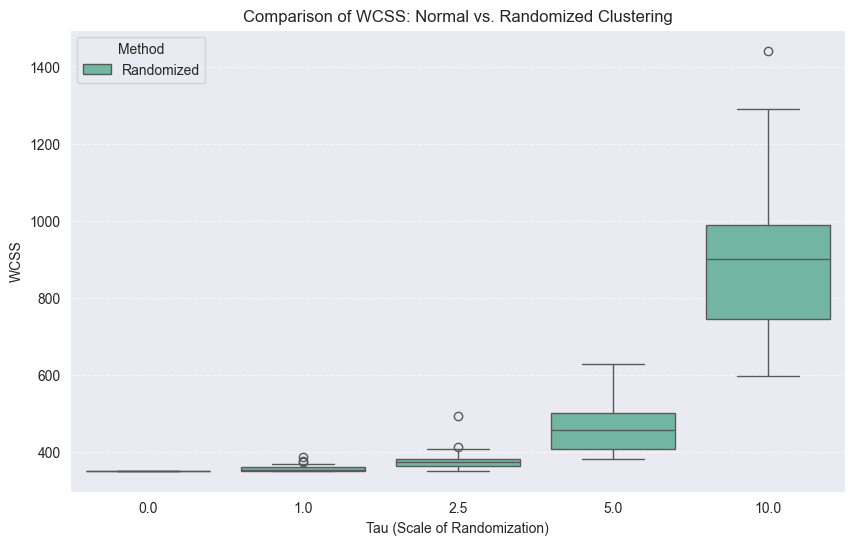

In [18]:
n = 200
tau_values = [0,1,2.5,5,10]
n_runs = 50
n_clusters = 5  
# Data collection
results = []

for tau in tau_values:
    for _ in range(n_runs):
        X, y = make_blobs(n_samples=n, centers=5, cluster_std=1,random_state=42)
        # Randomized hierarchical clustering
        randomized_clustering = AgglomerativeClustering(X, n_clusters=n_clusters, tau=tau)
        randomized_clustering.fit()
        randomized_score = randomized_clustering.compute_wcss()
        results.append({'Tau': tau, 'Method': 'Randomized', 'WCSS': randomized_score})

# Convert results to a DataFrame
df = pd.DataFrame(results)

# Create side-by-side boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Tau', y='WCSS', hue='Method', palette='Set2')
plt.title('Comparison of WCSS: Normal vs. Randomized Clustering')
plt.xlabel('Tau (Scale of Randomization)')
plt.ylabel('WCSS')
plt.legend(title='Method')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [6]:
print("Distance Log:")
for key, value in model.distance_log.items():
    print(f"{key}: {value}")

Distance Log:
(ClusterNode(points=[0]), ClusterNode(points=[1])): 12.315401347394783
(ClusterNode(points=[0]), ClusterNode(points=[2])): 10.822735675540768
(ClusterNode(points=[0]), ClusterNode(points=[3])): 6.901137882513095
(ClusterNode(points=[0]), ClusterNode(points=[4])): 9.290906625903663
(ClusterNode(points=[0]), ClusterNode(points=[5])): 6.267552491915872
(ClusterNode(points=[0]), ClusterNode(points=[6])): 11.5173832658688
(ClusterNode(points=[0]), ClusterNode(points=[7])): 10.244154655666948
(ClusterNode(points=[0]), ClusterNode(points=[8])): 12.78057556239168
(ClusterNode(points=[0]), ClusterNode(points=[9])): 11.110751216454084
(ClusterNode(points=[0]), ClusterNode(points=[10])): 12.297472603654157
(ClusterNode(points=[0]), ClusterNode(points=[11])): 4.987688058910583
(ClusterNode(points=[0]), ClusterNode(points=[12])): 7.042765510818272
(ClusterNode(points=[0]), ClusterNode(points=[13])): 11.30706311295155
(ClusterNode(points=[0]), ClusterNode(points=[14])): 13.961487589223

In [19]:
print("\nExisting Clusters Log:")
for key, value in model.existing_clusters_log.items():
    print(f"Merge: {key} -> Clusters: {value}")


Existing Clusters Log:
Merge: (ClusterNode(points=[50]), ClusterNode(points=[67])) -> Clusters: [ClusterNode(points=[0]), ClusterNode(points=[1]), ClusterNode(points=[2]), ClusterNode(points=[3]), ClusterNode(points=[4]), ClusterNode(points=[5]), ClusterNode(points=[6]), ClusterNode(points=[7]), ClusterNode(points=[8]), ClusterNode(points=[9]), ClusterNode(points=[10]), ClusterNode(points=[11]), ClusterNode(points=[12]), ClusterNode(points=[13]), ClusterNode(points=[14]), ClusterNode(points=[15]), ClusterNode(points=[16]), ClusterNode(points=[17]), ClusterNode(points=[18]), ClusterNode(points=[19]), ClusterNode(points=[20]), ClusterNode(points=[21]), ClusterNode(points=[22]), ClusterNode(points=[23]), ClusterNode(points=[24]), ClusterNode(points=[25]), ClusterNode(points=[26]), ClusterNode(points=[27]), ClusterNode(points=[28]), ClusterNode(points=[29]), ClusterNode(points=[30]), ClusterNode(points=[31]), ClusterNode(points=[32]), ClusterNode(points=[33]), ClusterNode(points=[34]), Cl

In [14]:
print("Randomization Log:")
for key, value in model.randomization_log.items():
    print(f"{key}: {value}")
    break

Randomization Log:
(ClusterNode(points=[0]), ClusterNode(points=[1])): {1: 0.919146523069616, 2: 0.060141917348255886, 3: 0.4556723472466009, 4: -1.0112319069833917, 5: 0.12115980052900432, 6: 0.24862208733120353, 7: 0.9112687451646231, 8: 1.1406556798928513, 9: 0.243124238798952, 10: 1.2362422516394895}
